In [51]:
import pandas as pd
import glob
import os
import numpy as np
import networkx as nx
import pickle
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import time
import re
import random

In [52]:
seed = 42
np.random.seed(seed)
random.seed(seed)

In [53]:
path = "Datos/Originales/Datos looks/*.csv"
files = glob.glob(path)

dfs = {}

for file in files:
    base = os.path.splitext(os.path.basename(file))[0]
    if base == 'product_2':
        dfs[base] = pd.read_csv(file, sep=';')
    else:
        dfs[base] = pd.read_csv(file, sep=',')


In [54]:
df_productos = pd.DataFrame()
for i in range(len(dfs['product_2'])):
    producto = pd.DataFrame(dfs['product_2'].iloc[i]).T
    df_merged = producto.merge(
        dfs['product_variant'][['color_id', 'season', 'size_id', 'product_id']],
        left_on='id',
        right_on='product_id',
        how='left'
    )
    df_merged = df_merged[df_merged['season']==7]
    df_merged = df_merged.drop(columns=['Unnamed: 0', 'product_id'])
    df_merged = df_merged.merge(
        dfs['color'][['id', 'name']],
        left_on='color_id',
        right_on='id',
        how='left'
    )
    df_merged = df_merged.drop(columns=['id_y', 'color_id'])
    df_merged = df_merged.merge(
        dfs['size'][['id', 'lookiero']],
        left_on='size_id',
        right_on='id',
        how='left'
    )
    df_merged = df_merged.drop(columns=['id', 'size_id'])
    df_merged = df_merged.merge(
        dfs['brand'][['id', 'name']],
        left_on='brand_id',
        right_on='id',
        how='left'
    )
    df_merged = df_merged.drop(columns=['id', 'brand_id'])
    df_merged = df_merged.merge(
        dfs['product_feature_value'][['id', 'feature_value_id', 'product_id']],
        left_on='id_x',
        right_on='product_id',
        how='left'
    )
    df_merged = df_merged.drop(columns=['product_id'])
    df_merged = df_merged.rename(columns={'id_x': 'id_producto'})
    df_merged = df_merged.merge(
        dfs['feature_value'][['id', 'feature_id', 'value']],
        left_on='feature_value_id',
        right_on='id',
        how='left'
    )
    
    df_merged = df_merged.drop(columns=['id_y'])
    df_merged = df_merged[['id_producto', 'title', 'season', 'name_x', 'lookiero', 'name_y','feature_id', 'value']]
    df_merged = df_merged.merge(
        dfs['feature'][['id', 'name']],
        left_on='feature_id',
        right_on='id',
        how='left'
    )
    df_merged = df_merged.drop(columns=['feature_id', 'id', 'season'])
    df_merged = df_merged.rename(columns={'name_x': 'color', 'name_y': 'marca', 'name':'caracteristica1', 'value':'caracteristica2'})
    df_merged = df_merged[df_merged['caracteristica1'].isin(['print', 'weather', 'style', 'fit'])]

    cols_all = ['title', 'color', 'lookiero', 'marca', 'fit', 'print', 'style', 'weather']

    df_pivot = df_merged.pivot_table(
    index=['id_producto', 'title', 'color', 'lookiero', 'marca'],
    columns='caracteristica1',
    values='caracteristica2',
    aggfunc='first'
    ).reset_index()

    for c in cols_all:
        if c not in df_pivot.columns:
            df_pivot[c] = pd.NA

    df_pivot = df_pivot[['id_producto'] + cols_all]

    def unir_valores_unicos(s):
        return ", ".join(s.dropna().astype(str).unique())

    producto = (
        df_pivot
        .groupby("id_producto")[cols_all]
        .agg(unir_valores_unicos)
        .reset_index()
    )
    producto = pd.DataFrame(producto)
    df_productos = pd.concat([df_productos, producto], ignore_index=True)

In [55]:
df_productos['tipo_producto'] = df_productos['title'].str.split(" ").str[1]

In [56]:
grupo_1_1= ['Pant', 'Jeans', 'Skirt', 'Short', 'Jean',
       'Shorts', 'pant', 'Falda']
grupo_1_2= ['Dress','Jumpsuit','Playsuit']
grupo_2_1 = ['Shirt', 'Top', 'Tshirt', 'T-shirt','T-shit']
grupo_2_2 = ['Sweater','Sweatshirt','Pullover']
grupo_2_3 = ['Cardigan']
grupo_3_1 = ['Jacket',  'Parka', 'Coat', 'Jakect', 'Trench', 'Jackect']
grupo_3_2 = ['Scarf', 'Foulard', 'Fular']
grupo_3_3 = ['Bag']

df_productos['Nivel'] = np.select(
    [
        df_productos['tipo_producto'].isin(grupo_1_1),
        df_productos['tipo_producto'].isin(grupo_1_2),
        df_productos['tipo_producto'].isin(grupo_2_1),
        df_productos['tipo_producto'].isin(grupo_2_2),
        df_productos['tipo_producto'].isin(grupo_2_3),
        df_productos['tipo_producto'].isin(grupo_3_1),
        df_productos['tipo_producto'].isin(grupo_3_2),
        df_productos['tipo_producto'].isin(grupo_3_3)
    ],
    [1.1, 1.2, 2.1, 2.2, 2.3, 3.1, 3.2, 3.3],
    default=1
)

In [57]:
neutros = ['smooth', 'bodoque', '']
geometricos = ['horizontal_stripes', 'vertical_stripes', 'geometric', 'polka_dot', 'checked', 'vichy', 'prince_of_wales', 'pied_de_poule', 'herringbone']
organicos = ['floral', 'sheets', 'tropical', 'cachemere']
atrevidos = ['animal_print', 'retro', 'printed', 'ethnic', 'gradient', 'army', 'other']
micros = ['miniprint']

df_productos['Estampado'] = np.select(
    [
        df_productos['print'].isin(neutros),
        df_productos['print'].isin(geometricos),
        df_productos['print'].isin(organicos),
        df_productos['print'].isin(atrevidos),
        df_productos['print'].isin(micros),
    ],
    ['neutros', 'geometricos', 'organicos', 'atrevidos', 'micros'],
    default=''         
).astype('object')

df_productos['Estampado'].replace('', np.nan, inplace=True)
df_productos = df_productos.drop(columns=['print'])

C:\Users\gorja\AppData\Local\Temp\ipykernel_31332\1320451333.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_productos['Estampado'].replace('', np.nan, inplace=True)


In [58]:
NE = ['white', 'black', 'grey', 'gray_light', 'grey_dark', 'silver', 'nude']
NT = ['camel', 'brown', 'brown_light', 'beige', 'sand', 'ecru', 'taupe', 'khaki']
NO = ['blue_dark', 'wine', 'indigo', 'aubergine', 'green_dark', 'garnet', 'blue_petrol']
A = ['red', 'blue_klein', 'fuchsia', 'coral', 'mustand', 'green', 'orange', 'yellow', 'gold', 'blue']
AS = ['pale_pink', 'lilac', 'baby_blue', 'mint', 'yellow_ligth', 'salmon', 'green_light', 'blue_turquoise', 'blue_light', 'pink', 'pistachio']
AI = ['rust', 'ochre', 'mandarine', 'strawberry', 'brick', 'jade', 'lemon', 'grey_blue', 'purple', 'crimson']

df_tmp = df_productos.copy()
df_tmp['color_single'] = df_tmp['color'].str.split(', ')
df_tmp = df_tmp.explode('color_single')

def clasifica_color(c):
    if c in NE:  return 'NE'
    if c in NT:  return 'NT'
    if c in NO:  return 'NO'
    if c in A:   return 'A'
    if c in AS:  return 'AS'
    if c in AI:  return 'AI'
    return np.nan

df_tmp['grupo_color'] = df_tmp['color_single'].map(clasifica_color)

df_productos['colores'] = (
    df_tmp.groupby(df_tmp.index)['grupo_color']
          .apply(lambda s: ','.join(sorted(set(s.dropna()))))
)

df_productos['colores'].replace('', np.nan, inplace=True)
df_productos = df_productos.drop(columns=['color'])

C:\Users\gorja\AppData\Local\Temp\ipykernel_31332\1305878469.py:28: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_productos['colores'].replace('', np.nan, inplace=True)


In [59]:
df_productos = df_productos[df_productos['id_producto'] != '2b3f3c42-ab8d-4ffd-a152-a4fd364f2090']

In [60]:
df_productos.to_csv('Datos/Transformados/csv_limpio.csv')

Construyendo Grafo...
   -> Grafo creado con 1125 nodos y 282376 aristas.
Buscando looks...
   -> Búsqueda completada en 97.36 segundos.
   -> Looks válidos encontrados: 1483329

=== TOP 10 LOOKS (Sin Repetir Prendas) ===
1. [A (Pantalón)] Score: 11.0 | ['Onlblush Jeans noos (1.1)', 'Denim Jacket sew  (3.1)', 'Croix Tshirt cotton (2.1)']
2. [A (Pantalón)] Score: 11.0 | ['Viseana Pant chino  (1.1)', 'Post Sweater plains  (2.2)', 'Fiery Tshirt plains  (2.1)']
3. [A (Pantalón)] Score: 11.0 | ['Vijules Jeans washed (1.1)', 'Laras Tshirt order (2.1)', 'Roxana Jacket pale (3.1)']
4. [A (Pantalón)] Score: 11.0 | ['Lindex Pant nice (1.1)', 'Leila Top ycoo  (2.1)', 'Jinx Jacket eight  (3.1)']
5. [A (Pantalón)] Score: 11.0 | ['Lindex Pant hannah (1.1)', 'Ava Tshirt season (2.1)', 'Maf Sweater V  (2.2)']
6. [A (Pantalón)] Score: 11.0 | ['Sally Jeans denim (1.1)', 'Jeanne Shirt dusty (2.1)', 'Acacia Jacket ward (3.1)']
7. [A (Pantalón)] Score: 11.0 | ['Edith Pant beng (1.1)', 'Darlim Top cerise  (

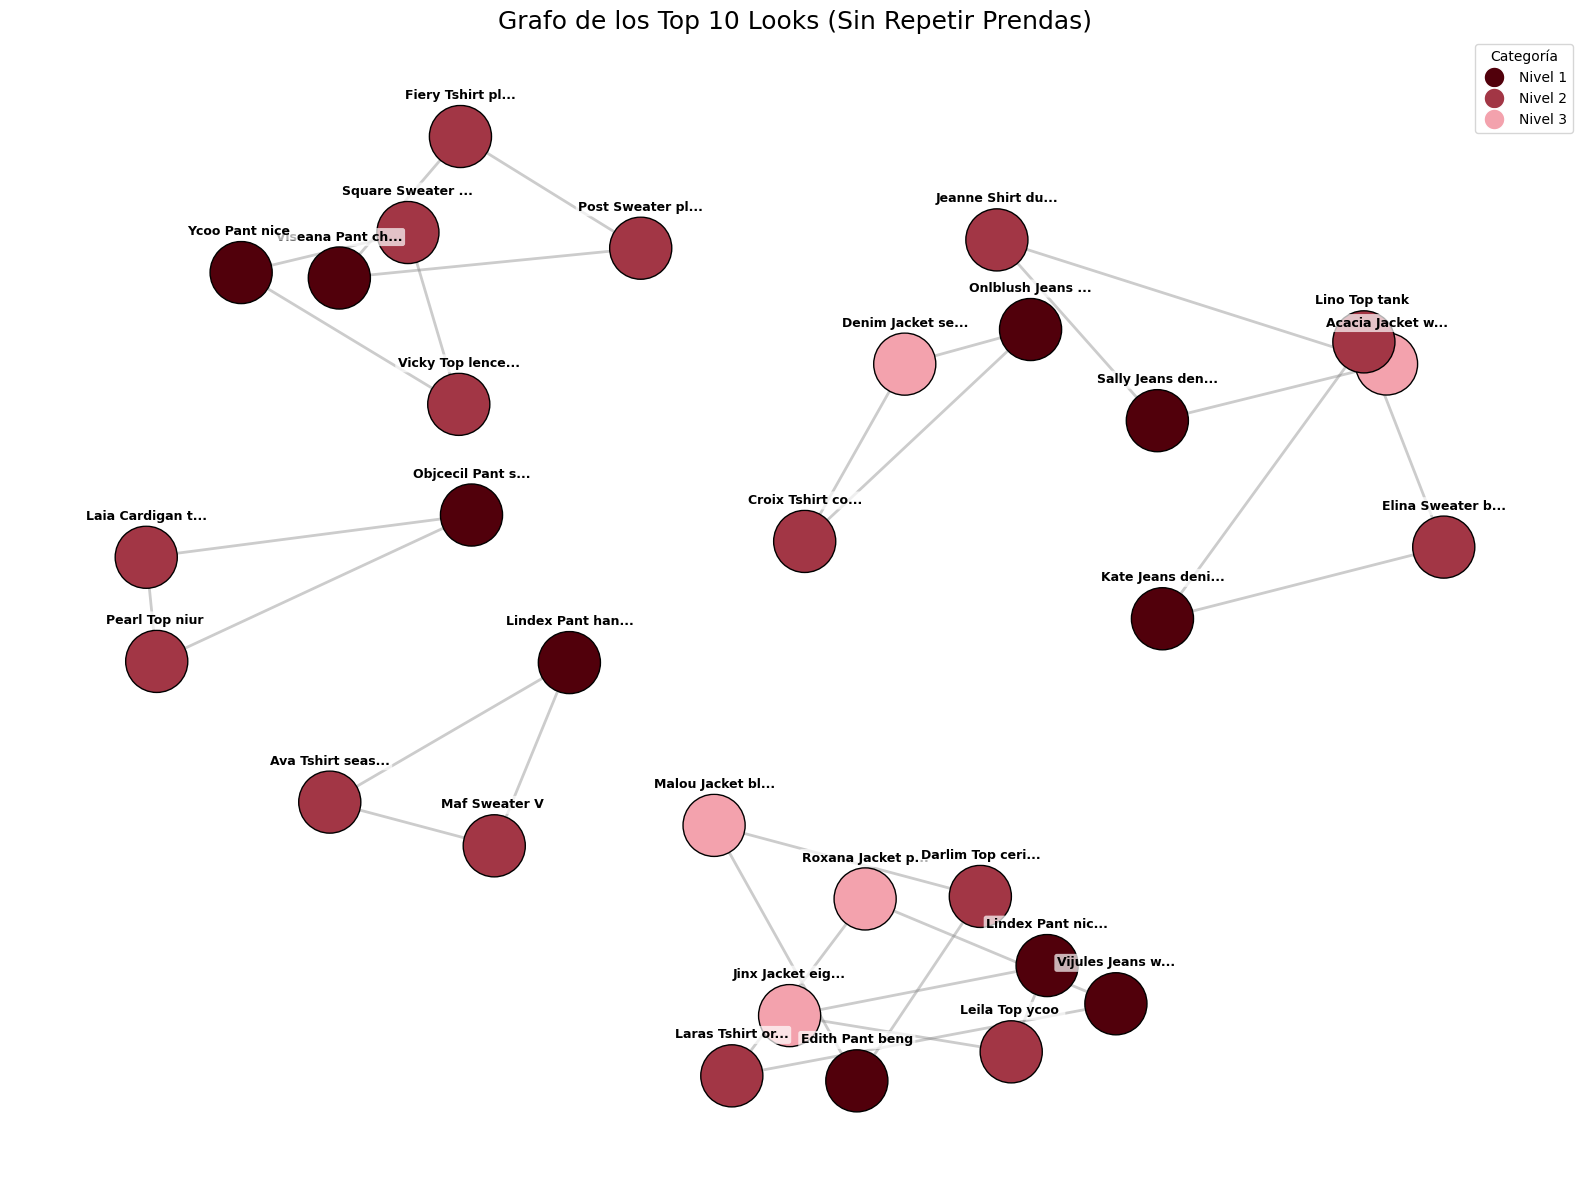

In [61]:
def parse_colors(color_str):
    if pd.isna(color_str): return set()
    return set(x.strip() for x in color_str.split(','))

def parse_sizes_json(json_str):
    if not isinstance(json_str, str): return set()
    try:
        if not json_str.strip().startswith('['): json_str = f"[{json_str}]"
        data = json.loads(json_str)
        return set(item['size'] for item in data)
    except:
        sizes = set(re.findall(r'"size":\s*"([^"]+)"', json_str))
        if not sizes: sizes = set(re.findall(r'""size"":\s*""([^"]+)""', json_str))
        return sizes

try:
    df = pd.read_csv('datos.csv')
except:
    if 'df_productos' in locals(): df = df_productos.copy()
    else: 
        print("ERROR: No se encontró 'datos.csv' ni 'df_productos'.")
        df = pd.DataFrame()

if not df.empty:
    df['color_groups'] = df['colores'].apply(parse_colors)
    df['sizes_set'] = df['lookiero'].apply(parse_sizes_json)
    df['fit'] = df['fit'].fillna('regular') 
    df['Nivel'] = df['Nivel'].astype(str)
    
    if 'color_pixel' in df.columns: df['color_final'] = df['color_pixel']
    elif 'color' in df.columns: df['color_final'] = df['color']
    else: df['color_final'] = df['colores']

    item_map = df.set_index('id_producto', drop=False).to_dict('index')
    items_by_level = {lvl: df[df['Nivel'] == lvl].to_dict('records') for lvl in df['Nivel'].unique()}


SIZE_VALS = {'XXS': 0, 'XS': 1, 'S': 2, 'M': 3, 'L': 4, 'XL': 5, 'XXL': 6, '2XL': 6, '3XL': 7, '4XL': 8, '5XL': 9}

def check_compatibility_score(p1, p2):
    """
    Retorna (True, Weight) si pueden conectarse, o (False, 0) si no.
    """
    if p1['Nivel'] == '2.1' and p2['Nivel'] == '2.1': return False, 0
    if p1['Nivel'] == '1.1' and p2['Nivel'] == '1.1': return False, 0

    is_acc = (p1['Nivel'] in ['3.2', '3.3']) or (p2['Nivel'] in ['3.2', '3.3'])
    if not is_acc:
        w1, w2 = p1.get('weather'), p2.get('weather')
        warm = ['warm', 'warm_season']
        cold = ['cold', 'cold_season']
        if (w1 in warm and w2 in cold) or (w1 in cold and w2 in warm): return False, 0
    
    def get_indices(p):
        if p['Nivel'] in ['3.2', '3.3']: return set(), True
        idxs = set()
        wild = False
        for s in p['sizes_set']:
            s_u = s.upper().strip()
            if s_u in ['UNQ', 'TU', 'ONE SIZE']: wild = True
            elif s_u in SIZE_VALS: idxs.add(SIZE_VALS[s_u])
        return idxs, wild

    i1, w1 = get_indices(p1)
    i2, w2 = get_indices(p2)
    
    compatible_size = False
    if w1 or w2: compatible_size = True
    else:
        for v1 in i1:
            for v2 in i2:
                if abs(v1 - v2) <= 3: 
                    compatible_size = True
                    break
    if not compatible_size: return False, 0

    s1, s2 = p1.get('style'), p2.get('style')
    bad = {('casual', 'night'), ('night', 'casual'), ('street', 'boho'), ('boho', 'street')}
    if (s1, s2) in bad: return False, 0

    weight = 1.0
    if s1 == s2: weight += 1.0
    if p1.get('Estampado') == p2.get('Estampado'): weight += 0.5
    if p1.get('fit') == p2.get('fit'): weight += 0.5
    
    return True, weight

def check_structure(items):
    lvls = [p['Nivel'] for p in items]
    
    if '1.1' in lvls and '2.1' in lvls:
        rem = list(lvls); rem.remove('1.1'); rem.remove('2.1')
        third = rem[0]
        if third in ['2.2', '2.3', '3.1', '3.3']: 
            return True, "A (Pantalón)"
            
    if '1.2' in lvls:
        has_second = ('2.3' in lvls) or ('3.1' in lvls)
        has_third = ('3.2' in lvls) or ('3.3' in lvls)
        if has_second and has_third: 
            return True, "B (Vestido)"
        
    return False, None

def check_color_rules_advanced(items):
    all_groups = [p['color_groups'] for p in items]
    
    if sum(1 for g in all_groups if 'A' in g) > 1: return False
    
    has_A = any('A' in g for g in all_groups)
    has_AI = any('AI' in g for g in all_groups)
    if has_A and has_AI: return False
    
    idx = [(0, all_groups[0]), (1, all_groups[1]), (2, all_groups[2])]
    for i in range(3):
        for j in range(3):
            if i == j: continue
            k = 3 - i - j
            g_i, g_j, g_k = idx[i][1], idx[j][1], idx[k][1]
            
            if 'NT' in g_i and 'A' in g_j and not ('NE' in g_k or 'NO' in g_k): return False
            if 'NE' in g_i and 'A' in g_j and not ('NE' in g_k or 'AS' in g_k): return False
            if 'NO' in g_i and 'AS' in g_j and not ('NT' in g_k or 'NE' in g_k): return False
            if 'NO' in g_i and 'NO' in g_j and not ('NE' in g_k or 'AS' in g_k or 'NT' in g_k): return False
            if 'AI' in g_i and 'NT' in g_j and not ('NE' in g_k or 'AS' in g_k): return False

    c = [p['color_final'] for p in items]
    n = [p['Nivel'] for p in items]
    pairs = [(0,1), (0,2), (1,2)]
    for x, y in pairs:
        if c[x] == c[y]:
            if not (n[x] == '3.2' or n[y] == '3.2'): return False
            
    return True

def check_extra_score_rules(items):
    score = 0
    prints = [p.get('Estampado') for p in items]
    neutros = prints.count('neutros')
    if not ('micros' in prints or neutros >= 2 or (len([x for x in prints if x!='neutros'])==1)):
        return -100 
    
    fits = [p.get('fit') for p in items]
    if len(set(fits)) == 1: score += 2.0
    elif 'tight' in fits and ('oversize' in fits or 'loose' in fits): score += 1.5
    
    return score

print("Construyendo Grafo...")
G = nx.Graph()
for pid, attrs in item_map.items():
    G.add_node(pid, **attrs)

l1 = items_by_level.get('1.1', []) + items_by_level.get('1.2', [])
l2 = items_by_level.get('2.1', []) + items_by_level.get('2.2', []) + items_by_level.get('2.3', [])
l3 = items_by_level.get('3.1', []) + items_by_level.get('3.2', []) + items_by_level.get('3.3', [])

def connect(g1, g2):
    count = 0
    for pa in g1:
        for pb in g2:
            if pa['id_producto'] == pb['id_producto']: continue
            ok, w = check_compatibility_score(pa, pb)
            if ok:
                G.add_edge(pa['id_producto'], pb['id_producto'], weight=w)
                count += 1
    return count

connect(l1, l2)
connect(l2, l3)
connect(l1, l3) 
connect(l2, l2) 
connect(l3, l3) 
print(f"   -> Grafo creado con {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas.")


print("Buscando looks...")
start_time = time.time()
found_outfits = []

set_l2 = set(p['id_producto'] for p in l2)
set_l3 = set(p['id_producto'] for p in l3)

for p1_data in l1:
    n1 = p1_data['id_producto']
    vecinos_n1 = set(G.neighbors(n1))
    
    candidatos_n2 = vecinos_n1.intersection(set_l2.union(set_l3))
    
    for n2 in candidatos_n2:
        vecinos_n2 = set(G.neighbors(n2))
        comunes = vecinos_n1.intersection(vecinos_n2)
        
        candidatos_n3 = comunes.intersection(set_l3.union(set_l2))
        
        for n3 in candidatos_n3:
            if n2 > n3: continue 

            items = [G.nodes[n1], G.nodes[n2], G.nodes[n3]]
            
            ok_struct, rule = check_structure(items)
            if not ok_struct: continue
            
            if not check_color_rules_advanced(items): continue
            
            bonus = check_extra_score_rules(items)
            if bonus < 0: continue
            
            base = G[n1][n2]['weight'] + G[n2][n3]['weight'] + G[n1][n3]['weight']
            
            found_outfits.append({
                'items': items,
                'score': base + bonus,
                'rule': rule
            })

elapsed = time.time() - start_time
print(f"   -> Búsqueda completada en {elapsed:.2f} segundos.")
print(f"   -> Looks válidos encontrados: {len(found_outfits)}")


found_outfits.sort(key=lambda x: x['score'], reverse=True)

final_top_looks = []
used_ids_global = set()

print("\n=== TOP 10 LOOKS (Sin Repetir Prendas) ===")

for look in found_outfits:
    current_ids = set(p['id_producto'] for p in look['items'])
    
    if current_ids.isdisjoint(used_ids_global):
        final_top_looks.append(look)
        used_ids_global.update(current_ids)
        
    if len(final_top_looks) == 10: break

for i, look in enumerate(final_top_looks):
    desc = [f"{p.get('title')} ({p.get('Nivel')})" for p in look['items']]
    print(f"{i+1}. [{look['rule']}] Score: {look['score']:.1f} | {desc}")

csv_data = []
for i, look in enumerate(final_top_looks):
    csv_data.append({
        'Ranking': i + 1,
        'Regla': look['rule'],
        'Score Total': round(look['score'], 2),
        'Item 1 ID': look['items'][0]['id_producto'],
        'Item 1 Nombre': look['items'][0].get('title', ''),
        'Item 2 ID': look['items'][1]['id_producto'],
        'Item 2 Nombre': look['items'][1].get('title', ''),
        'Item 3 ID': look['items'][2]['id_producto'],
        'Item 3 Nombre': look['items'][2].get('title', '')
    })

df_export = pd.DataFrame(csv_data)
df_export.to_csv('Datos/Transformados/top_10_outfits.csv', index=False, encoding='utf-8-sig')
print(f"\n¡Éxito! Se ha creado el archivo 'top_10_outfits.csv' con {len(df_export)} looks.")


if final_top_looks:
    print("\nGenerando visualización del grafo...")
    plt.figure(figsize=(16, 12))
    G_viz = nx.Graph()
    node_colors = []
    labels = {}
    
    for look in final_top_looks:
        ids = [p['id_producto'] for p in look['items']]
        G_viz.add_node(ids[0], **look['items'][0])
        G_viz.add_node(ids[1], **look['items'][1])
        G_viz.add_node(ids[2], **look['items'][2])
        
        G_viz.add_edge(ids[0], ids[1])
        G_viz.add_edge(ids[1], ids[2])
        G_viz.add_edge(ids[0], ids[2])
    
    COLOR_NIVEL_1 = '#51000B' 
    COLOR_NIVEL_2 = '#A23645' 
    COLOR_NIVEL_3 = '#F3A2AD' 
    
    for node in G_viz.nodes():
        lvl = str(G_viz.nodes[node]['Nivel'])
        title_full = G_viz.nodes[node].get('title', str(node))
        if len(title_full) > 15:
            labels[node] = title_full[:15] + "..."
        else:
            labels[node] = title_full
        
        if lvl.startswith('1'): node_colors.append(COLOR_NIVEL_1) 
        elif lvl.startswith('2'): node_colors.append(COLOR_NIVEL_2)
        else: node_colors.append(COLOR_NIVEL_3)

    pos = nx.spring_layout(G_viz, k=0.8, seed=42) 
    
    nx.draw_networkx_nodes(G_viz, pos, node_size=2000, node_color=node_colors, edgecolors='black')
    nx.draw_networkx_edges(G_viz, pos, width=2, alpha=0.4, edge_color='gray')
    
    pos_labels = {k: (v[0], v[1] + 0.08) for k, v in pos.items()}
    
    nx.draw_networkx_labels(
        G_viz, 
        pos_labels,
        labels, 
        font_size=9, 
        font_color='black', 
        font_weight="bold",
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2') 
    )
    
    plt.title("Grafo de los Top 10 Looks (Sin Repetir Prendas)", fontsize=18)
    plt.axis('off')
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Nivel 1',
               markerfacecolor=COLOR_NIVEL_1, markersize=15),
        Line2D([0], [0], marker='o', color='w', label='Nivel 2',
               markerfacecolor=COLOR_NIVEL_2, markersize=15),
        Line2D([0], [0], marker='o', color='w', label='Nivel 3',
               markerfacecolor=COLOR_NIVEL_3, markersize=15)
    ]
    plt.legend(handles=legend_elements, loc='upper right', title="Categoría", fontsize=10)
   
    plt.tight_layout()
    plt.show()

In [62]:
with open("Grafo/grafo_lookiero.gpickle", "wb") as f:
    pickle.dump(G, f)

Número de nodos: 1125
Número de aristas: 282376
Densidad del grafo: 0.44662079873467775
La prenda más combinable es: Arel Bag gold 
Índice de centralidad: 1.0000
Total de prendas aisladas (sin combinaciones): 0
Número de grupos de ropa desconectados (componentes): 1
Promedio de combinaciones por prenda: 502.00
Diámetro del grafo (distancia máxima entre prendas): 2
Calculando Coeficiente de Clustering (esto puede tardar unos segundos)...
-> Coeficiente de Clustering Promedio: 0.6179
Detectando comunidades de estilo...
-> Número de comunidades (grupos de estilo) detectados: 3
   - Comunidad 1: 483 prendas.
   - Comunidad 2: 386 prendas.
   - Comunidad 3: 256 prendas.
Generando Histograma de Conexiones...


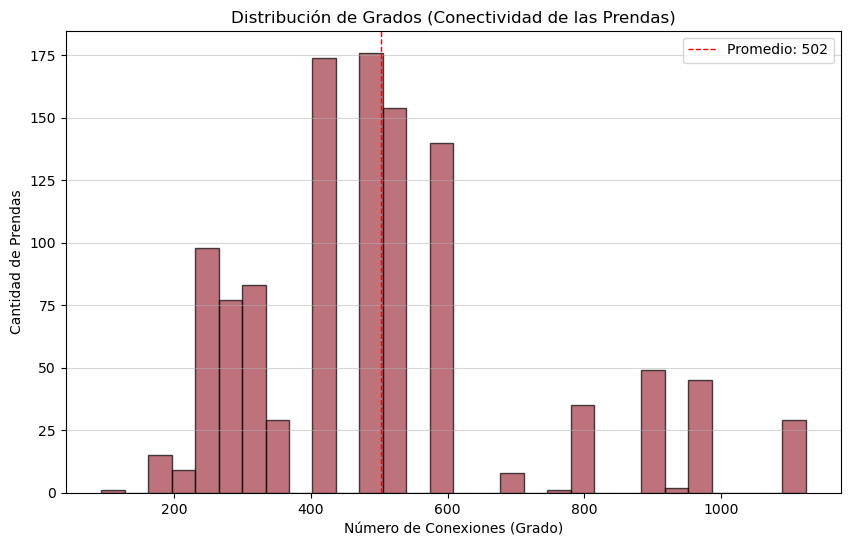

In [63]:
print("Número de nodos:", G.number_of_nodes())
print("Número de aristas:", G.number_of_edges())
print("Densidad del grafo:", nx.density(G))
centralidad = nx.degree_centrality(G)
prenda_top = max(centralidad, key=centralidad.get)
valor_top = centralidad[prenda_top]
nombre_prenda = (df_productos[df_productos['id_producto']==prenda_top]['title']).to_list()

print(f"La prenda más combinable es: {nombre_prenda[0]}")
print(f"Índice de centralidad: {valor_top:.4f}")

nodos_aislados = list(nx.isolates(G))
print(f"Total de prendas aisladas (sin combinaciones): {len(nodos_aislados)}")

if len(nodos_aislados) > 0:
    print(f"Ejemplos de prendas aisladas: {nodos_aislados[:5]}")

if G.is_directed():
    num_componentes = nx.number_weakly_connected_components(G)
    print(f"Número de grupos de ropa desconectados (componentes): {num_componentes}")
else:
    num_componentes = nx.number_connected_components(G)
    print(f"Número de grupos de ropa desconectados (componentes): {num_componentes}")

grados = [grado for nodo, grado in G.degree()]
grado_promedio = sum(grados) / len(grados)
print(f"Promedio de combinaciones por prenda: {grado_promedio:.2f}")

try:
    if nx.is_connected(G.to_undirected()): 
        diametro = nx.diameter(G.to_undirected())
        print(f"Diámetro del grafo (distancia máxima entre prendas): {diametro}")
    else:
        print("El grafo no está conectado (hay islas), no se puede calcular diámetro global.")
except:
    print("Cálculo de diámetro omitido (demasiado costoso computacionalmente).")

print("Calculando Coeficiente de Clustering (esto puede tardar unos segundos)...")
clustering_avg = nx.average_clustering(G)
print(f"-> Coeficiente de Clustering Promedio: {clustering_avg:.4f}")

print("Detectando comunidades de estilo...")
try:
    communities = nx.community.louvain_communities(G, seed=42)
    print(f"-> Número de comunidades (grupos de estilo) detectados: {len(communities)}")
    
    communities = sorted(communities, key=len, reverse=True)
    for i, comm in enumerate(communities[:3]):
        print(f"   - Comunidad {i+1}: {len(comm)} prendas.")
except Exception as e:
    print(f"-> No se pudo calcular Louvain (posiblemente falte scipy): {e}")

print("Generando Histograma de Conexiones...")
degrees = [degree for node, degree in G.degree()]

plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=30, color='#A23645', edgecolor='black', alpha=0.7)
plt.title("Distribución de Grados (Conectividad de las Prendas)")
plt.xlabel("Número de Conexiones (Grado)")
plt.ylabel("Cantidad de Prendas")
plt.axvline(sum(degrees)/len(degrees), color='red', linestyle='dashed', linewidth=1, label=f'Promedio: {sum(degrees)/len(degrees):.0f}')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()